# Data Wrangling and Visualization in Python

## 1. LOAD PACKAGES

In [2]:
import pandas as pd # Dot data manipulation
import seaborn as sns # For visualization
import matplotlib.pyplot as plt  # For visualization

## 2. LOAD AND EXPLORE DATA

In [3]:
# A. Load iris dataset from seaborn package
iris = sns.load_dataset('iris')

In [4]:
# Get the name of the variables
print(iris.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [5]:
# Examine the object type, DataFrame
type(iris)

pandas.core.frame.DataFrame

In [6]:
# A. Load iris dataset from a GitHub repo

# URL to the raw CSV file
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

# Read the CSV directly from the web
df = pd.read_csv(url)

In [7]:
type(df)

pandas.core.frame.DataFrame

In [8]:
# Display the first few rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# Get statistical summary of all numerical variables
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3: DATA WRANGLING

In [10]:
# --- Example 3a: Create new variables, filter, and sort
iris.assign(sepal_area = df['sepal_length'] * df['sepal_width'] ).query('sepal_length > 5').sort_values(by = 'sepal_area', ascending=False)

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
131,7.9,3.8,6.4,2.0,virginica,30.02
117,7.7,3.8,6.7,2.2,virginica,29.26
109,7.2,3.6,6.1,2.5,virginica,25.92
15,5.7,4.4,1.5,0.4,setosa,25.08
14,5.8,4.0,1.2,0.2,setosa,23.20
...,...,...,...,...,...,...
62,6.0,2.2,4.0,1.0,versicolor,13.20
81,5.5,2.4,3.7,1.0,versicolor,13.20
80,5.5,2.4,3.8,1.1,versicolor,13.20
98,5.1,2.5,3.0,1.1,versicolor,12.75


In [11]:
# Example 3b: Summarise data by groups
iris_mean = iris.groupby('species')['petal_length'].agg(['count', 'mean', 'median']).reset_index()

In [12]:
iris_mean

,species,count,mean,median
0,setosa,50,1.462,1.50
1,versicolor,50,4.260,4.35
2,virginica,50,5.552,5.55


## 4: VISUALIZATION

In [ ]:
# Set theme of graphs
sns.set_theme(style = 'whitegrid')

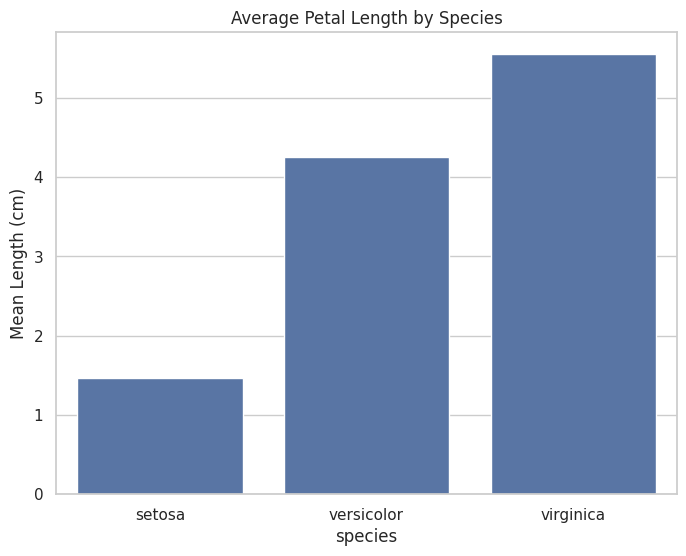

In [ ]:
# 4a: Bar Chart
plt.figure(figsize=(8,6))
sns.barplot(data = iris_mean, x = 'species', y = "mean")
plt.title('Average Petal Length by Species')
plt.ylabel('Mean Length (cm)')
plt.show()

<Axes: xlabel='sepal_width', ylabel='Count'>

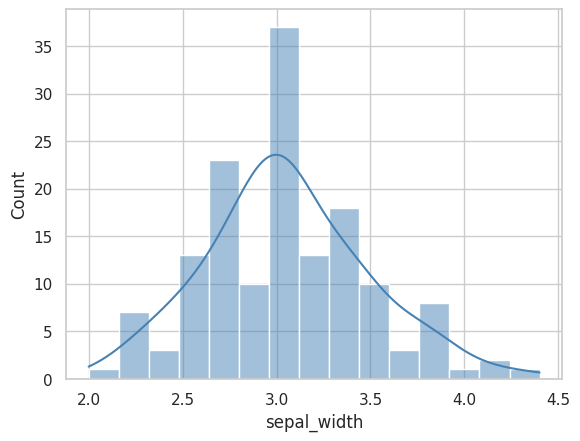

In [ ]:
# 4b: Histogram
sns.histplot(data=iris, x='sepal_width', bins=15, kde=True, color='steelblue')

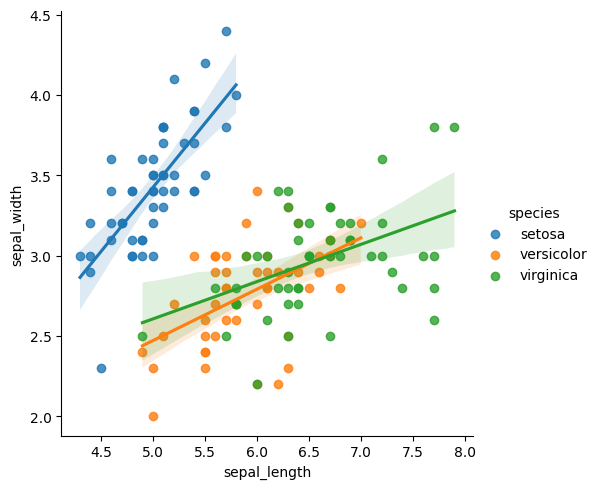

In [13]:
# 4c: Scatter Plot with Linear Regression

scatter_plot = sns.lmplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue = 'species'
)

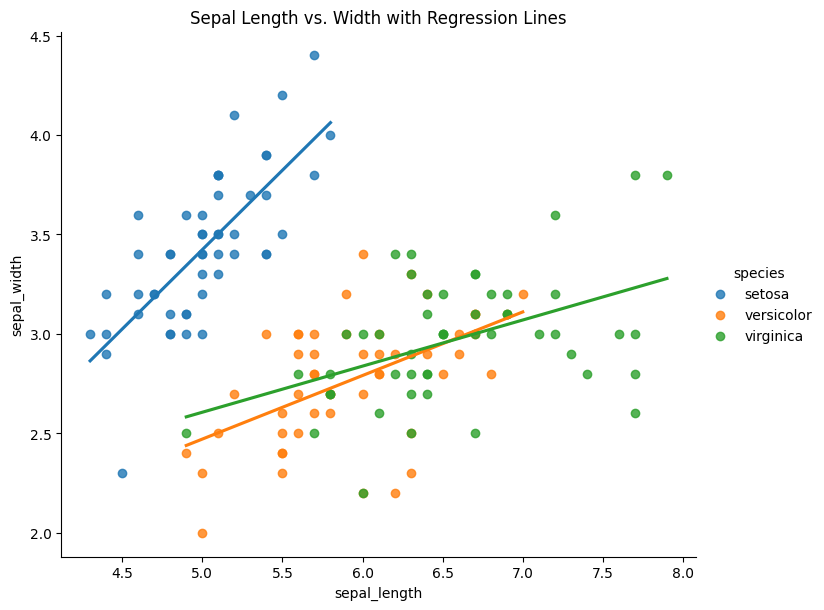

In [15]:
# 4d: Scatter Plot with Linear Regression
scatter_plot = sns.lmplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue='species',    # This is like aes(color = Species)
    height=6,
    aspect=1.2,
    ci=None           # Equivalent to se=FALSE in ggplot
)
plt.title('Sepal Length vs. Width with Regression Lines')
plt.show()

In [14]:
plt.show()

# 5: EXPORTING FIGURES

In [16]:
scatter_plot.savefig("iris_scatterplot.png")